<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [25]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
    !pip install langdetect
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [26]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt
import numpy as np

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display
from langdetect import detect

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [27]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_3.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [28]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
df = df.sample(n=100, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_3.gzip.parquet


## Output Path


In [29]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28


In [30]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
133553,ac6a759b4f119793cbdd6c3758f094aee37c83bb26,Oh Lindsay! https://93de50b06721bdbffea671af631e5977848a5b4678,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,None,None,2013-09-16 23:24:04,bb43e3ae271651d1c69e95bd3e34c61ef7867edfa9,27. ☼ Sexy guapura. ☼ 3b14da620405da1db13a9c9f2678a318a3fabafd3a. 🔥 •Love Only c74491dbc90ddbb88dd63c36f97a0c16eec3047b3c•,1695,1234,2010-06-17,True,258129a5623335cbdc91042889f883a3597a57ef3a,5966fe58e5fe7ae898b8495f777b976093d9e20fc4,[],[https://93de50b06721bdbffea671af631e5977848a5b4678],[258129a5623335cbdc91042889f883a3597a57ef3a],True
109427,53dccb76465a3f753924aeff8ef0542edce3ae7d48,"@7865a1ce4e30ed18052a3b4313526d32e728e103e6: Rina Rivas, primera Venezolana en votar. Viajó muchos kilómetros en Australia: https://51663410ede3936187243164f84c3a5f3e93e102a0",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-04-13 23:03:34,7865a1ce4e30ed18052a3b4313526d32e728e103e6,"Nuestro principal objetivo es ofrecer lo mejor en el mundo del espectáculo, entretenimiento y algo más para que usted este informado.",19468,3899,2009-08-27,True,9124834ec18a63f241ab083d35517f039c344ecbc2,5761fb0e5f606ff783f62e6185e2f6645a13905e5c,[],[https://51663410ede3936187243164f84c3a5f3e93e102a0],"[9124834ec18a63f241ab083d35517f039c344ecbc2, 7865a1ce4e30ed18052a3b4313526d32e728e103e6]",True
100199,2153dd7ee9780936ece78e98aece13c0d135cecfba,I'm such a sweetheart. I'm really not that mean 😇,b3fe5629e3785802d35446f0bf198fb766c55b257d,en,None,None,2013-02-22 07:55:25,b05c6fb7347b1999dba1ea1e0696794d1855468f49,Black and Italian boss. Mother of King Kash. Plastic platform heels bring home the bacon. Snapchat: 919176756907581b5b8e01b1d7923f5f38932d712a,995,519,2011-07-26,False,None,None,[],[],[],True
112447,98ab86861690aa89908e7fc0485262f637ca317a66,Aparecemos en el especial del Día del Niño de @0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 https://0f08c27b02adedb08210862d5e558abefae682137f ¿Uds. qué harían si fueran niños otra vez? #FelizDíadelNiño,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2013-04-30 19:40:02,0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2,En/el medio de la Ciudad.,121136,134,2010-04-07,True,291eff4169d215b998ab4f2bb5c3721528427cfecf,b08c38b7d6d1b4d9b94eb2f524e33bf291064f4b5e,[FelizDíadelNiño],[https://0f08c27b02adedb08210862d5e558abefae682137f],"[291eff4169d215b998ab4f2bb5c3721528427cfecf, 0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2]",True
139489,041e2cccf89ef069a19a10e65509140bd47ab85ea6,Curso presencial: #PHP 5.3 orientada a la certificación #Zend #Quito #Ecuador https://0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe,6ff22b61515ffcfdf7aeed07fadbc38c40567d4708,es,None,None,2013-10-22 20:49:55,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,El chulla bot tweetea todo acerca de Quito... de leyff.,2749,1686,2010-05-24,True,735a52e61a651158d896fa289b7835af9e709a1bda,74418eeef94b141954c82e3803ca01ac06dc5ab83b,"[PHP, Zend, Quito, Ecuador]",[https://0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe],[735a52e61a651158d896fa289b7835af9e709a1bda],True


## Logs

In [31]:
from functools import wraps
from datetime import datetime



REPORT_PATH = output_folder_path / "progress_report.txt"

def write_report(msg: str):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"{timestamp} | {msg}"

    print(line)
    with open(REPORT_PATH, "a") as f:
        f.write(line + "\n")


def report_done(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            result = func(*args, **kwargs)
            write_report(f"Completed: {func.__name__}")
            return result
        except Exception as e:
            write_report(f"FAILED: {func.__name__} | {e}")
            raise
    return wrapper

# Dataset Statistics

In [32]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]
start_date = df["post_time"].min().strftime("%Y-%m")
end_date = df["post_time"].max().strftime("%Y-%m")

stats_text = [
    f"Posts time range: {start_date} → {end_date}",
    "",
    f"{'df shape:':<40} {df.shape}",
    f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)",
    f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)",
    f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)",
]

# print to console
print("\n".join(stats_text))

# save to file
if output_folder_path:
    output_folder_path = Path(output_folder_path)
    report_path = output_folder_path / "dataset_summary.txt"
    with open(report_path, "w") as f:
        f.write("\n".join(stats_text))

print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

Posts time range: 2013-02 → 2014-01

df shape:                                (100, 19)
df posts with hashtags # shape:          (52, 19)  (52.00%)
df posts with account_mentions @ shape:  (64, 19)  (64.00%)
df posts with urls shape:                (45, 19)  (45.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | nd

# Clean Text

## Clean text With Entities

In [33]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token

In [34]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [35]:
df["clean_text_with_entities"] = df["post_text"].apply(clean_text)

## Clean Text Without Enttities

In [36]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [37]:
df["clean_text_without_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [38]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_without_enteties"]].sample(n=20)

,post_text,clean_text_without_enteties
120304,@5cd8fc1f85de41d5ed91e2126b73c11f370ff72d51 Educación es Moral y Luces Simón Bolívar #Venezuela #SOSUnive EXIGE Salarios Dignos Presupuestos Justos https://6e47b7b3048b88eb9d41d602798ceb24fcdd5d2115,<USER> educación es moral y luces simón bolívar venezuela sosunive exige salarios dignos presupuestos justos <URL>
139489,Curso presencial: #PHP 5.3 orientada a la certificación #Zend #Quito #Ecuador https://0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe,curso presencial: php 5.3 orientada a la certificación zend quito ecuador <URL>
112144,Tenemos lo que buscas para mejorar tu reputación y tu imagen corporativa... Planes a la medida de tu presupuesto. https://639f061ef238a39ff4de084f6908db1980f5cbbbf6,tenemos lo que buscas para mejorar tu reputación y tu imagen corporativa... planes a la medida de tu presupuesto. <URL>
115177,#Good #Tuesday to all Our Friends who are fighting Against #cancerdisease.,good tuesday to all our friends who are fighting against cancerdisease.
118619,.@deb69b53b710dc2bd1ac635267fbdd9bba33201436: Suramérica es territorio de paz y no de guerra #OTAN #COLOMBIA https://6666c88b26179c8f2468a9f4539ff910d4406c71ce,.<USER>: suramérica es territorio de paz y no de guerra otan colombia <URL>
137213,Pero tengo una brújula. #Dios,pero tengo una brújula. dios
142651,#Quito #Ecuador https://ace994ddabbbca4501a3d2ab97fc6f01820b409ea7,quito ecuador <URL>
126803,"@f7a0d9fcb31cdaf84143db22e9511bbf674db43b32 \n“La grandeza humana se expresa, cuando la humildad está presente en los diferentes actos de la vida.“ JVC. SDT.","<USER> “la grandeza humana se expresa, cuando la humildad está presente en los diferentes actos de la vida.“ jvc. sdt."
148492,#news Musei gratis (per un giorno) in tutta Italia: Sabato 28 dicembre in tutti i luoghi d’arte n... https://6495e7bcc13f7b4926bd94ade85d7ef13885f6569f #italia,news musei gratis (per un giorno) in tutta italia: sabato 28 dicembre in tutti i luoghi d’arte n... <URL> italia
104144,@cd8653192dcfa7b72a8d11df60e72fc8f8041336bc yo voy en julio o en marzoo te visitare jeje,<USER> yo voy en julio o en marzoo te visitare jeje


# Translation to English

In [ ]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str, text: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in map, auto-detect the language from text.
    Args:
        lang_code (str): Post language code.
        text (str): Post text for detection.
    Returns:
        str: NLLB-200 language code.
    """
    nllb_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian
    "sl": "slv_Latn",    # Slovenian
    "cs": "ces_Latn",    # Czech
    "da": "dan_Latn",    # Danish
    "no": "nob_Latn",    # Norwegian Bokmål
    "is": "isl_Latn",    # Icelandic
    "fi": "fin_Latn",    # Finnish
    "hu": "hun_Latn",    # Hungarian
    "ro": "ron_Latn",    # Romanian
    "bg": "bul_Cyrl",    # Bulgarian
    "uk": "ukr_Cyrl",    # Ukrainian
    "lt": "lit_Latn",    # Lithuanian
    "lv": "lvs_Latn",    # Latvian
    "sq": "als_Latn",    # Albanian
    "eu": "eus_Latn",   # Basque
    "hr": "hrv_Latn",   # Croatian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali
    "ta": "tam_Taml",   # Tamil

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)
    "th": "tha_Thai",   # Thai

    # Africa
    "sw": "swh_Latn",   # Swahili
    "so": "som_Latn",   # Somali

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
    "ht": "hat_Latn",   # Haitian Creole
    
}


    # 1. direct mapping
    if lang_code in nllb_mapping:
        return nllb_mapping[lang_code]

    # 2. language detection
    try:
        detected = detect(text)
    except Exception as e:
        write_report(f"Language detection failed: {e} | text={text[:100]}")
        return lang_code

    # 3. mapping detected language
    if detected in nllb_mapping:
        return nllb_mapping[detected]

    write_report(f"No NLLB mapping for detected language: {detected}")
    return lang_code

In [40]:
print(df["post_language"].value_counts())    

post_language
es     59
en     23
und     5
pt      3
it      2
ca      1
ja      1
hi      1
fr      1
in      1
Name: count, dtype: int64


In [41]:
df["post_language"] = df.apply(lambda row: map_to_nllb_code(row['post_language'], row['clean_text_without_enteties']), axis=1)

In [42]:
language_value_counts = df["post_language"].value_counts()
write_report(f"Undefined post language percentage: {language_value_counts.get('und', 0) / len(df) * 100:.2f}%")
display(language_value_counts)


2025-12-28 11:11:13 | Undefined post language percentage: 0.00%


post_language
spa_Latn    62
eng_Latn    25
por_Latn     3
ita_Latn     3
cat_Latn     1
jpn_Jpan     1
hin_Deva     1
deu_Latn     1
fra_Latn     1
ind_Latn     1
cym_Latn     1
Name: count, dtype: int64

In [ ]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, torch_dtype=torch.float16, max_length=1024, batch_size=8)

Using device: cuda


Device set to use cuda


In [ ]:
from tqdm.auto import tqdm
import subprocess

@report_done
def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_with_entities",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None


    # print memory summary
    write_report(subprocess.check_output('nvidia-smi', shell=True).decode())

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):


        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            write_report(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            write_report(f"{target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [45]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (100, 21)


Translating by language:   0%|          | 0/11 [00:00<?, ?it/s]

2025-12-28 11:11:16 | Sun Dec 28 11:11:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 30%   40C    P0             34W /  300W |   19914MiB /  49140MiB |     18%      Default |
|                                         |                        |                  N/A |
+-------------------------

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2025-12-28 11:11:32 | Sun Dec 28 11:11:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 30%   48C    P0            144W /  300W |   19934MiB /  49140MiB |     36%      Default |
|                                         |                        |                  N/A |
+-------------------------

In [46]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_without_enteties", "translated_post"]]

,clean_text_without_enteties,translated_post
100199,i'm such a sweetheart. i'm really not that mean 😇,I'm so sweet. I'm not really that bad EMOJI_smile_face_with_halo
148063,blackberry 9320 desbloqueado para las 3 operadoras! excelente estado! $120! <USER>,Blackberry 9320 unlocked for all three operators! excellent condition! $120! MENTION_26f980c1c19f5ba5847420be4435e1aa3e9066b5c3
125045,siempre hay un momento de inspiración y reflexión en nuestras vidas motivad<USER> por algo o alguien que nos regocija el alma.,There's always a moment of inspiration and reflection in our lives motivated by something or someone that makes our soul rejoice.
139489,curso presencial: php 5.3 orientada a la certificación zend quito ecuador <URL>,HASHTAG_zend HASHTAG_quito HASHTAG_ecuador URL_0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe
146734,gente to achando que não é hj a maite no programa raul gil até agora não falaram nada!!tem certeza que é hj gente?,The people who think it's not her in Raul Gil's show haven't said anything yet. Are you sure it's her people?
111732,"<USER> <USER> rt camaradas, algo huele mal en el banco bicentenario por: luis alberto duarte <URL>","MENTION_59e7fc296a60876c1c4b819d8a68b5a8413198a34a MENTION_1c7d3707d171049387f97ff018c46a0107be8062e5 comrades, something stinks at the bicentenary bank by: luis alberto duarte URL_09431ecf7d88607df5ea94a3703bab8f0c806441a0"
108270,"y cuando la bestia de mario silva dijo a alguien x ahí ""hijo de puta"" rt <USER>: como cuando ... <URL>","And when Mario Silva's beast said to someone x there ""son of a bitch"" rt MENTION_0c5d8eaab6f2d9c147be840d74372cbe3a8cb708e6: like when ... URL_dce67889b1733f02614fca220be75aa085b72eef1e"
117240,"mi novio nunca está cuando lo necesito, tampoco cuando no lo necesito, de hecho no está nunca, la verdad es que no tengo novi…","My boyfriend's never around when I need him, nor is he around when I don't need him, in fact he's never around, the truth is I don't have a boyfriend..."
115269,good bye anying!!,Farewell to all!!
109427,"<USER>: rina rivas, primera venezolana en votar. viajó muchos kilómetros en australia: <URL>","MENTION_7865a1ce4e30ed18052a3b4313526d32e728e103e6 : rina rivas, first venezuelan woman to vote. travelled many kilometres in australia: URL_51663410ede3936187243164f84c3a5f3e93e102a0"


# Remove Engllish Stopwords

In [47]:
from nltk.corpus import stopwords
import nltk

In [48]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    if not text:
        return text
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [49]:
df["clean_text_with_entities"] = df["clean_text_with_entities"].apply(remove_stopwords)
df["clean_text_without_enteties"] = df["clean_text_without_enteties"].apply(remove_stopwords)
df["translated_post"] = df["translated_post"].apply(remove_stopwords)

In [50]:
df[["post_text", "clean_text_with_entities"]].head(20)

,post_text,clean_text_with_entities
133553,Oh Lindsay! https://93de50b06721bdbffea671af631e5977848a5b4678,lindsay! url_93de50b06721bdbffea671af631e5977848a5b4678
109427,"@7865a1ce4e30ed18052a3b4313526d32e728e103e6: Rina Rivas, primera Venezolana en votar. Viajó muchos kilómetros en Australia: https://51663410ede3936187243164f84c3a5f3e93e102a0","mention_7865a1ce4e30ed18052a3b4313526d32e728e103e6 : rina rivas, primera venezolana en votar. viajó muchos kilómetros en australia: url_51663410ede3936187243164f84c3a5f3e93e102a0"
100199,I'm such a sweetheart. I'm really not that mean 😇,sweetheart. mean emoji_smiling_face_with_halo
112447,Aparecemos en el especial del Día del Niño de @0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 https://0f08c27b02adedb08210862d5e558abefae682137f ¿Uds. qué harían si fueran niños otra vez? #FelizDíadelNiño,aparecemos en el especial del día del niño de mention_0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 url_0f08c27b02adedb08210862d5e558abefae682137f ¿uds. qué harían si fueran niños otra vez? hashtag_felizdíadelniño
139489,Curso presencial: #PHP 5.3 orientada a la certificación #Zend #Quito #Ecuador https://0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe,curso presencial: hashtag_php 5.3 orientada la certificación hashtag_zend hashtag_quito hashtag_ecuador url_0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe
142724,#QuintaSinfonia desde #Quito con @17295cb59d53751de170596cf3ee17b9e530d90dd9 escuchamos a @4c595c836f18927bdde2a76a1eda18b11c0d15ed97 - Tu amor es un sueno https://42679656157f3f53402142d1a6d7e7ccc1d8b15c77,hashtag_quintasinfonia desde hashtag_quito con mention_17295cb59d53751de170596cf3ee17b9e530d90dd9 escuchamos mention_4c595c836f18927bdde2a76a1eda18b11c0d15ed97 - tu amor es un sueno url_42679656157f3f53402142d1a6d7e7ccc1d8b15c77
110822,"El ignorante critica porque cree saberlo todo, el sabio respeta porque reconoce que puede aprender algo nuevo.","el ignorante critica porque cree saberlo todo, el sabio respeta porque reconoce que puede aprender algo nuevo."
149498,@ded1941d5fd7fa9a8ceaea1410e351c9a60668b071: #Ecuador Metas según plan del Buen Vivir 2013-2017 relacionadas con las TIC´s https://6001625665ee9f4bfb59eb66c304098389776a90c6,mention_ded1941d5fd7fa9a8ceaea1410e351c9a60668b071 : hashtag_ecuador metas según plan del buen vivir 2013-2017 relacionadas con las tic´s url_6001625665ee9f4bfb59eb66c304098389776a90c6
104144,@cd8653192dcfa7b72a8d11df60e72fc8f8041336bc yo voy en julio o en marzoo te visitare jeje,mention_cd8653192dcfa7b72a8d11df60e72fc8f8041336bc yo voy en julio en marzoo te visitare jeje
136958,"Hace 20 años, #Emelec jugó contra #NOB en el regreso de Diego Maradona. Un niño llamado Lionel Messi lo veia desde las gradas.","hace 20 años, hashtag_emelec jugó contra hashtag_nob en el regreso de diego maradona. un niño llamado lionel messi lo veia desde las gradas."


# Handling *None* Cells

In [51]:
display(df[df["translated_post"].isna()][["post_text", "post_language", "clean_text_without_enteties", "translated_post"]])

# Check if more than 5% of posts are untranslated
num_untranslated = df["translated_post"].isna().sum()
total_posts = len(df)
percentage_untranslated = (num_untranslated / total_posts) * 100

write_report(f"Untranslated posts: {num_untranslated}/{total_posts} ({percentage_untranslated:.2f}%)")
if percentage_untranslated > 10:
    raise ValueError(f"More than 10% of posts are untranslated: {percentage_untranslated:.2f}%")

# Fill untranslated posts with original cleaned text
df["translated_post"] = df["translated_post"].fillna(df["clean_text_without_enteties"])

,post_text,post_language,clean_text_without_enteties,translated_post


2025-12-28 11:12:02 | Untranslated posts: 0/100 (0.00%)


# English Topic Clustering

Note: the topic clustering doent influenced by the entities since it is preformed on the text without the entitites.

## Utils


### Posts Topic Stats

In [52]:
@report_done
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [53]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path: str | Path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")

    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum()}",
        ],
        loc="best",
    )


    plt.tight_layout()


    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

### Accoutns Topic Stats

In [54]:
@report_done
def make_topic_account_stats(
    df: pd.DataFrame,
    topic_col: str,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Compute per-topic unique account counts (IO vs control) using an author-level threshold.

    Args:
        df: Post-level DataFrame.
        topic_col: Topic column name.
        author_col: Author identifier column.
        is_control_col: Column where 1 = control, 0 = IO.
        threshold: IO-rate threshold to label an author as IO (1 = IO).

    Returns:
        DataFrame with per-topic counts of unique IO/control accounts and IO percentage.
    """
    # Author-level IO rate: 1 - mean(is_control)
    author_io_rate = 1 - df.groupby(author_col)[is_control_col].mean()
    author_io_tag = (author_io_rate >= threshold).astype(int)

    topic_author_df = df[[topic_col, author_col]].drop_duplicates().copy()
    topic_author_df["author_io_tag"] = topic_author_df[author_col].map(author_io_tag)

    stats = (
        topic_author_df
        .groupby(topic_col)["author_io_tag"]
        .value_counts()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist even if absent in data
    stats = stats.reindex(columns=[0, 1], fill_value=0).rename(
        columns={0: "control_accounts", 1: "io_accounts"}
    ).reset_index()

    stats["total_accounts"] = stats["control_accounts"] + stats["io_accounts"]
    stats["io_percent"] = (stats["io_accounts"] / stats["total_accounts"]).mul(100)

    return stats

In [55]:
def plot_topic_account_stats(
    topic_account_stats: pd.DataFrame,
    topic_col_name: str,
    model_name: str,
    output_folder_path: Path | str | None = None,
):
    """Plot IO vs control account counts per topic.

    Args:
        topic_account_stats: Output of make_topic_account_stats().
        topic_col_name: Topic column name.
        model_name: Model name for title / filename.
        output_folder_path: Optional folder to save the plot.

    Returns:
        None
    """
    topics = topic_account_stats[topic_col_name]
    io_count = topic_account_stats["io_accounts"]
    control_count = topic_account_stats["control_accounts"]
    io_percent = topic_account_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO accounts
    bar_io = plt.bar(topics, io_count, label="IO accounts", color="red")

    # 🔵 Top: Control accounts
    bar_control = plt.bar(
        topics,
        control_count,
        bottom=io_count,
        label="Control accounts",
    )

    # Add IO percentage text
    ax = plt.gca()
    for x, io, ctrl, pct in zip(topics, io_count, control_count, io_percent):
        total = io + ctrl
        ax.text(
            x,
            total + 0.3,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular",
        )

    plt.title(f"Unique Accounts per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Unique Accounts")
    plt.xticks(topics)
    plt.grid(axis="y")

    # Legend with extra info lines
    percent_legend = Line2D([], [], color="none")
    total_accounts_legend = Line2D([], [], color="none")

    plt.legend(
        handles=[bar_io, bar_control, percent_legend, total_accounts_legend],
        labels=[
            "IO accounts",
            "Control accounts",
            "% IO Accounts Ratio",
            f"Total accounts: {topic_account_stats["total_accounts"].sum()}",
        ],
        loc="best",
    )

    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / f"{model_name}_topic_accounts.png"
        plt.savefig(plot_file_path, dpi=300)
        print(f"Plot saved to {plot_file_path}")

    plt.show()
    plt.close()

### Embeddings

In [56]:
from sklearn.preprocessing import normalize

# List of posts' text
translated_clean_posts_text_lst = df["translated_post"].to_list()

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(translated_clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [57]:
import subprocess

@report_done
def english_BERTopic_modeling(
        posts_text_lst: list[str], 
        embeddings: np.ndarray, 
        output_folder_path: str | Path = "", 
        min_topic_size: int = 50
    ):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    # print memory summary
    write_report(f"english_BERTopic_modeling: \n {subprocess.check_output('nvidia-smi', shell=True).decode()}")

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model

In [58]:
import math

min_topic_size = int(min(len(df) / 10, int(math.log(len(df)) * 25))) # 1M -> 150
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(translated_clean_posts_text_lst, embeddings, output_folder_path = output_folder_path, min_topic_size = min_topic_size) # dont save the model because this is too big

df["BERTopic_topic"] = BERTopic_topic
df["BERTopic_prob"] = BERT_probs


BERTopic_model.get_topic_info()

2025-12-28 11:12:04,437 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2025-12-28 11:12:04 | english_BERTopic_modeling: 
 Sun Dec 28 11:12:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 30%   56C    P0             85W /  300W |   32226MiB /  49140MiB |      3%      Default |
|                                         |                        |                  N/A

2025-12-28 11:12:13,033 - BERTopic - Dimensionality - Completed ✓
2025-12-28 11:12:13,034 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-28 11:12:13,038 - BERTopic - Cluster - Completed ✓
2025-12-28 11:12:13,040 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-28 11:12:13,049 - BERTopic - Representation - Completed ✓
2025-12-28 11:12:13,056 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28
2025-12-28 11:12:13 | Completed: english_BERTopic_modeling


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_ll_back_right_night,"[ll, back, right, night, hashtagnob, fucking, hashtagguayacas, diego, another, hashtagemelec]","[let's go another night! hashtag_guayacas hashtag_quito *tourist fucking night luxury!, twenty years ago, hashtag_emelec played hashtag_nob return diego maradona. boy named lionel messi saw stands., 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back .]"
1,0,65,0_hashtagquito_thirsty_via_subparagraph,"[hashtagquito, thirsty, via, subparagraph, hashtag, hashtagrt, hashtagecuador, first, best, recommend]","[recommend anyone wants promote it, musicians, event planners, on! hashtag_rt hashtag_mutual followback hashtag_sougo hashtag_automatic follow hashtag_sougofollow hashtag_ diffusion, addition, important note case first subparagraph paragraph 1 first subparagraph paragraph 1 article, following subparagraph added:, hashtag_thirsty please thirsty thirsty thirsty thirsty thirsty thirsty thirsty thirsty thirsty thirsty]"
2,1,32,1_hey_girl_country_around,"[hey, girl, country, around, today, cant, also, mentions, photo, maybe]","[ignorant criticizes thinks knows everything, wise man respects recognizes learn something new., hey, jerry, crystal, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl, country girl., hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey.]"


In [59]:
@report_done
def make_topic_top_posts_table(
    df,
    topic_col="BERTopic_topic",
    prob_col="BERTopic_prob",
    text_col="translated_post",
    top_k=5,
    output_folder_path: Path | str | None = None,
):
    """Make a df with the top k posts with the highest BERTopic probability for each topic."""

    top_posts = (
        df[[topic_col, prob_col, text_col]]
        .dropna(subset=[topic_col, prob_col, text_col])
        .sort_values([topic_col, prob_col], ascending=[True, False])
        .drop_duplicates(subset=[topic_col, text_col])  # remove duplicates within topic
        .groupby(topic_col)
        .head(top_k)
        .copy()
    )

    top_posts["rank"] = top_posts.groupby(topic_col).cumcount() + 1

    top_posts = top_posts.pivot(
        index=topic_col,
        columns="rank",
        values=text_col,
    )

    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        df_output_path = output_folder_path / "topics_top_posts.parquet"
        top_posts.to_parquet(df_output_path, compression="gzip")
        print(f"Topic posts table is saved to {df_output_path}")

    return top_posts

In [60]:
topic_posts_table = make_topic_top_posts_table(df, output_folder_path = output_folder_path)
display(topic_posts_table.head())

Topic posts table is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/topics_top_posts.parquet
2025-12-28 11:12:13 | Completed: make_topic_top_posts_table


rank,1,2,3,4,5
BERTopic_topic,,,,,
-1,"twenty years ago, hashtag_emelec played hashtag_nob return diego maradona. boy named lionel messi saw stands.","'ll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back , 'll right back .",let's go another night! hashtag_guayacas hashtag_quito *tourist fucking night luxury!,NaN,NaN
0,appearing special mention_0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 url_0f08c27b02adedb08210862d5e558abefae682137f kids again?,mention_cd8653192dcfa7b72a8d11df60e72fc8f8041336bc,best memories hashtag_danzarabe always carry me! miss u mention_4743041f03bd16f418e6d3d8214e1a8f6e954b940a url_15b94bed43cc40bb5e7bb3fac4cceb6d681525e933,mention_7d96ef33fcf93a9551ff9cd242a28589403985514c yes course explain right... private,mention_bc8f9cc92b3524738e34b1a93eaf71c2a63dca6ed9 mention_961513e47c0685192736da74e6f51de0c1aeda8498 mention_e612071d91d98f5f91e22e7d59a9f95786547ab661 mention_64dbcabc7871ec7f7802baf705852ef239e4198
1,"friday, love.",today call grandmother peace .,can't believe stayed till today.,"photo fb, wa, bbm, etece, there's 99.5% chance bager that's photo went well.",week pointless seen alpha male.


2025-12-28 11:12:13 | Completed: make_topic_stats
plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/BERTopic_topic_clustering.png


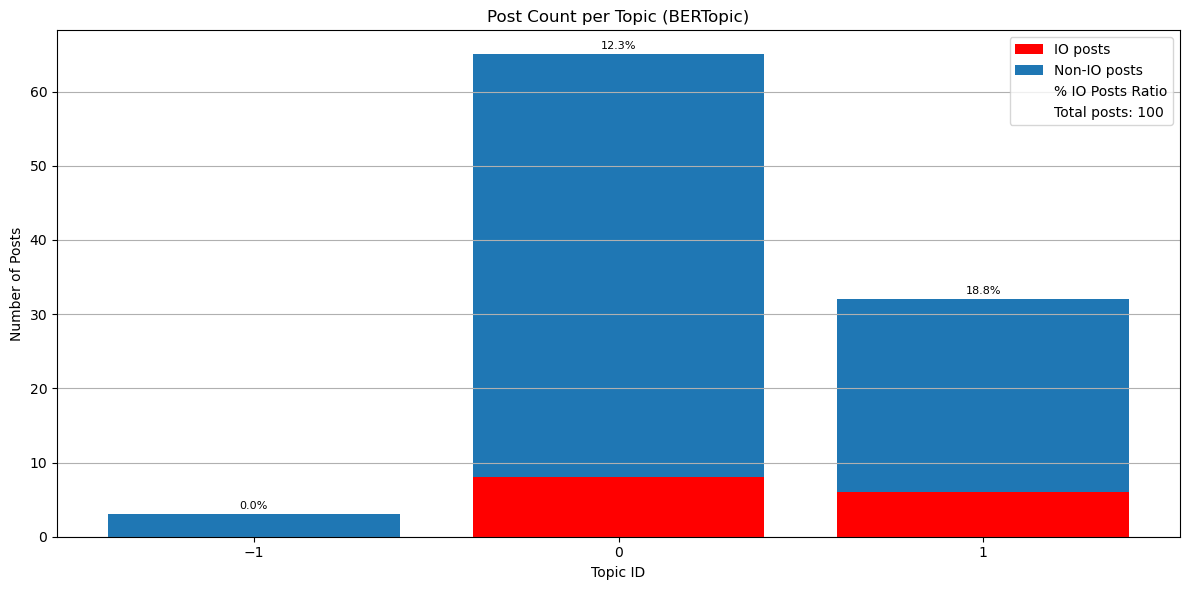

In [61]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

2025-12-28 11:12:13 | Completed: make_topic_account_stats


author_io_tag,BERTopic_topic,control_accounts,io_accounts,total_accounts,io_percent
0,-1,3,0,3,0.000000
1,0,45,4,49,8.163265
2,1,24,5,29,17.241379


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/BERTopic_topic_accounts.png


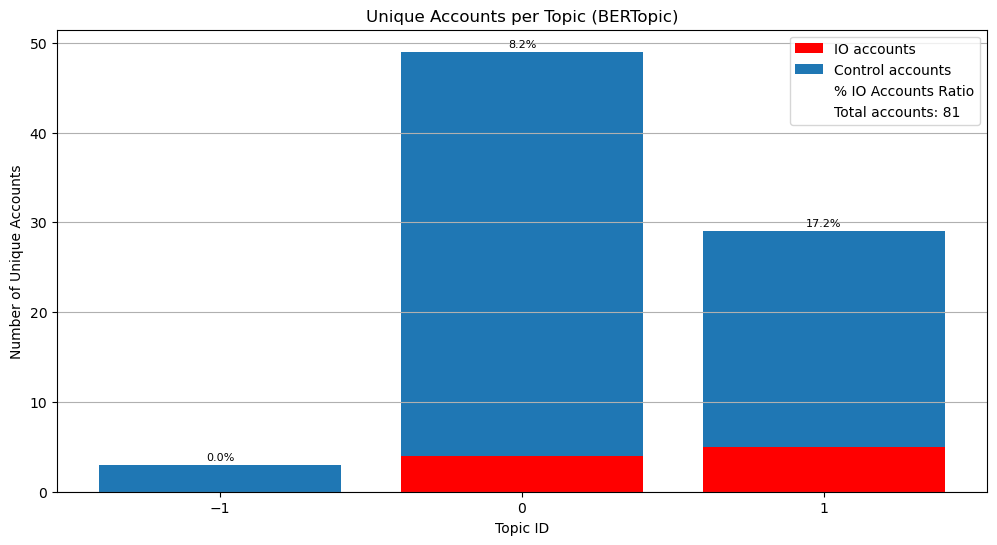

In [62]:
topic_col_name = "BERTopic_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "BERTopic", output_folder_path)

In [63]:
try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: zero-size array to reduction operation maximum which has no identity


## K-Means

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import subprocess

@report_done
def auto_kmeans_topics(embeddings, k_min=30, k_max=200, step = 4):
    best_k = None
    best_score = -1
    best_labels = None

    # print memory summary
    write_report(f"auto_kmeans_topics: \n {subprocess.check_output('nvidia-smi', shell=True).decode()}")

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [65]:
import math

n = len(df)

k_min = max(3, int(math.log(n)))
print(f"k_min = {k_min}")
k_max = min(200 ,int(math.sqrt(n)))
print(f"k_max = {k_max}")

labels, best_k = auto_kmeans_topics(embeddings, k_min=k_min, k_max=k_max)
df["K_Means_topic"] = labels
print(f"\nBest k: {best_k}")
df.head()

k_min = 4
k_max = 10


2025-12-28 11:12:14 | auto_kmeans_topics: 
 Sun Dec 28 11:12:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:21:00.0 Off |                  Off |
| 30%   52C    P0             68W /  300W |   32226MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+---

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,hashtags,urls,account_mentions,is_control,clean_text_with_entities,clean_text_without_enteties,translated_post,BERTopic_topic,BERTopic_prob,K_Means_topic
133553,ac6a759b4f119793cbdd6c3758f094aee37c83bb26,Oh Lindsay! https://93de50b06721bdbffea671af631e5977848a5b4678,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,eng_Latn,None,None,2013-09-16 23:24:04,bb43e3ae271651d1c69e95bd3e34c61ef7867edfa9,27. ☼ Sexy guapura. ☼ 3b14da620405da1db13a9c9f2678a318a3fabafd3a. 🔥 •Love Only c74491dbc90ddbb88dd63c36f97a0c16eec3047b3c•,1695,...,[],[https://93de50b06721bdbffea671af631e5977848a5b4678],[258129a5623335cbdc91042889f883a3597a57ef3a],True,lindsay! url_93de50b06721bdbffea671af631e5977848a5b4678,lindsay! <url>,lindsay! url_93de50b06721bdbffea671af631e5977848a5b4678,0,0.842338,1
109427,53dccb76465a3f753924aeff8ef0542edce3ae7d48,"@7865a1ce4e30ed18052a3b4313526d32e728e103e6: Rina Rivas, primera Venezolana en votar. Viajó muchos kilómetros en Australia: https://51663410ede3936187243164f84c3a5f3e93e102a0",62010408238d4a0f958ec97eec3db0a4f69bcd0d11,spa_Latn,None,None,2013-04-13 23:03:34,7865a1ce4e30ed18052a3b4313526d32e728e103e6,"Nuestro principal objetivo es ofrecer lo mejor en el mundo del espectáculo, entretenimiento y algo más para que usted este informado.",19468,...,[],[https://51663410ede3936187243164f84c3a5f3e93e102a0],"[9124834ec18a63f241ab083d35517f039c344ecbc2, 7865a1ce4e30ed18052a3b4313526d32e728e103e6]",True,"mention_7865a1ce4e30ed18052a3b4313526d32e728e103e6 : rina rivas, primera venezolana en votar. viajó muchos kilómetros en australia: url_51663410ede3936187243164f84c3a5f3e93e102a0","<user>: rina rivas, primera venezolana en votar. viajó muchos kilómetros en australia: <url>","mention_7865a1ce4e30ed18052a3b4313526d32e728e103e6 : rina rivas, first venezuelan woman vote. travelled many kilometres australia: url_51663410ede3936187243164f84c3a5f3e93e102a0",0,0.871160,1
100199,2153dd7ee9780936ece78e98aece13c0d135cecfba,I'm such a sweetheart. I'm really not that mean 😇,b3fe5629e3785802d35446f0bf198fb766c55b257d,eng_Latn,None,None,2013-02-22 07:55:25,b05c6fb7347b1999dba1ea1e0696794d1855468f49,Black and Italian boss. Mother of King Kash. Plastic platform heels bring home the bacon. Snapchat: 919176756907581b5b8e01b1d7923f5f38932d712a,995,...,[],[],[],True,sweetheart. mean emoji_smiling_face_with_halo,sweetheart. mean 😇,sweet. bad emoji_smile_face_with_halo,1,0.663682,3
112447,98ab86861690aa89908e7fc0485262f637ca317a66,Aparecemos en el especial del Día del Niño de @0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 https://0f08c27b02adedb08210862d5e558abefae682137f ¿Uds. qué harían si fueran niños otra vez? #FelizDíadelNiño,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,spa_Latn,None,None,2013-04-30 19:40:02,0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2,En/el medio de la Ciudad.,121136,...,[FelizDíadelNiño],[https://0f08c27b02adedb08210862d5e558abefae682137f],"[291eff4169d215b998ab4f2bb5c3721528427cfecf, 0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2]",True,aparecemos en el especial del día del niño de mention_0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 url_0f08c27b02adedb08210862d5e558abefae682137f ¿uds. qué harían si fueran niños otra vez? hashtag_felizdíadelniño,aparecemos en el especial del día del niño de <user> <url> ¿uds. qué harían si fueran niños otra vez? felizdíadelniño,appearing special mention_0b6db8f3378efff6ebcea84c452c5c7ec74261e4c2 url_0f08c27b02adedb08210862d5e558abefae682137f kids again?,0,1.000000,0
139489,041e2cccf89ef069a19a10e65509140bd47ab85ea6,Curso presencial: #PHP 5.3 orientada a la certificación #Zend #Quito #Ecuador https://0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe,6ff22b61515ffcfdf7aeed07fadbc38c40567d4708,spa_Latn,None,None,2013-10-22 20:49:55,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,El chulla bot tweetea todo acerca de Quito... de leyff.,2749,...,"[PHP, Zend, Quito, Ecuador]"

2025-12-28 11:12:14 | Completed: make_topic_stats
plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/K-Means_topic_clustering.png


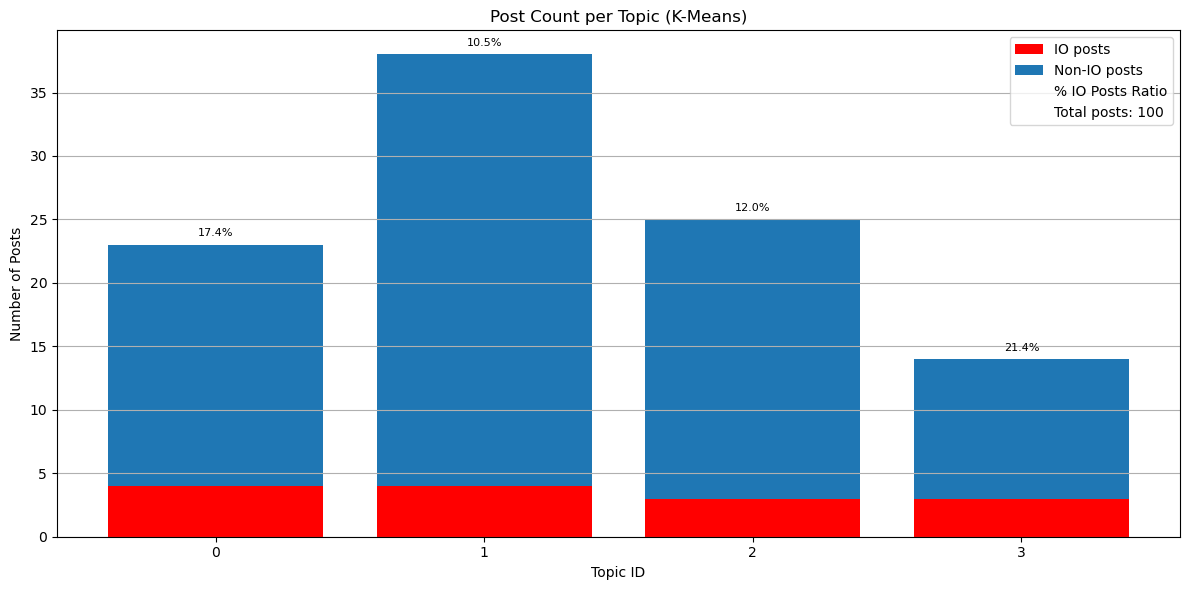

In [66]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

2025-12-28 11:12:15 | Completed: make_topic_account_stats


author_io_tag,K_Means_topic,control_accounts,io_accounts,total_accounts,io_percent
0,0,17,3,20,15.000000
1,1,26,2,28,7.142857
2,2,19,3,22,13.636364
3,3,11,2,13,15.384615


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/K_Means_topic_accounts.png


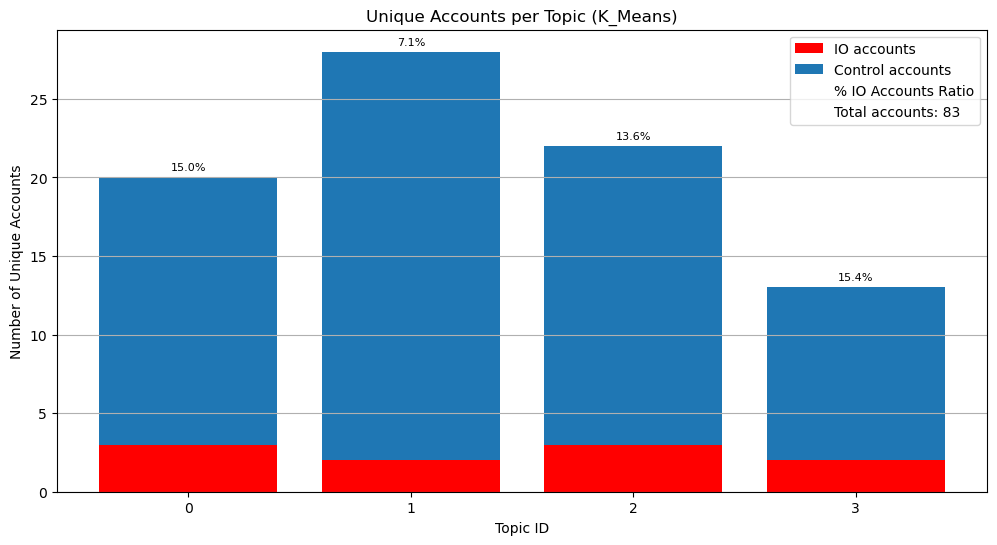

In [67]:
topic_col_name = "K_Means_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "K_Means", output_folder_path)

# Named Entity Recognition

In [68]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

@report_done
def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [69]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["translated_post"].to_list())

2025-12-28 11:12:17 | Completed: extract_ner_entities


In [70]:
# display post with ner entities
df.loc[df["ner_entities"].astype(bool), ["post_text", "translated_post", "ner_entities"]].head()

,post_text,translated_post,ner_entities
133553,Oh Lindsay! https://93de50b06721bdbffea671af631e5977848a5b4678,lindsay! url_93de50b06721bdbffea671af631e5977848a5b4678,[lindsay@@]
109427,"@7865a1ce4e30ed18052a3b4313526d32e728e103e6: Rina Rivas, primera Venezolana en votar. Viajó muchos kilómetros en Australia: https://51663410ede3936187243164f84c3a5f3e93e102a0","mention_7865a1ce4e30ed18052a3b4313526d32e728e103e6 : rina rivas, first venezuelan woman vote. travelled many kilometres australia: url_51663410ede3936187243164f84c3a5f3e93e102a0","[rina ri@@, venezuelan, austr@@, ali@@]"
139489,Curso presencial: #PHP 5.3 orientada a la certificación #Zend #Quito #Ecuador https://0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe,hashtag_zend hashtag_quito hashtag_ecuador url_0a3fe78c3cb9d2e4b04d7d6d66923545e70672e1fe,[ecuador]
149498,@ded1941d5fd7fa9a8ceaea1410e351c9a60668b071: #Ecuador Metas según plan del Buen Vivir 2013-2017 relacionadas con las TIC´s https://6001625665ee9f4bfb59eb66c304098389776a90c6,mention_ded1941d5fd7fa9a8ceaea1410e351c9a60668b071 : hashtag_ecuador goals according plan good living 2013-2017 related tic's url_6001625665ee9f4bfb59eb66c304098389776a90c6,[ecuador]
136958,"Hace 20 años, #Emelec jugó contra #NOB en el regreso de Diego Maradona. Un niño llamado Lionel Messi lo veia desde las gradas.","twenty years ago, hashtag_emelec played hashtag_nob return diego maradona. boy named lionel messi saw stands.","[emelec, diego marad@@, lionel messi]"


# Clean Entities

In [71]:
@report_done
def clean_entity_columns(df, entity_cols_lst):
    """Normalize entity columns to match TfidfVectorizer behavior.

    Converts each entity to a stripped, lowercase string for all columns
    listed in ``entity_cols_lst``.
    The function modifies ``df``.

    Args:
        df: Input DataFrame.
        entity_cols_lst: Columns containing lists of entities.

    Returns:
        None.
    """
    for col in entity_cols_lst:
        df[col] = df[col].apply(lambda lst: [str(e).strip().lower().replace(" ", "_") for e in lst])

In [72]:
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]
clean_entity_columns(df, entity_cols_lst)

2025-12-28 11:12:17 | Completed: clean_entity_columns


# Entities Statistics

In [73]:
@report_done
def entity_topic_counts(
    df: pd.DataFrame,
    entity_col: str,
    topic_col: str,
) -> pd.DataFrame:
    """Return entity-topic count matrix.

    Args:
        df: Input DataFrame.
        entity_col: Column with entity IDs (list-like).
        topic_col: Column with topic labels.

    Returns:
        DataFrame with entities as index, topics as columns, counts as values.
    """
    
    df_exploded = (
        df[[entity_col, topic_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col, topic_col])
    )

    return pd.crosstab(
        index=df_exploded[entity_col],
        columns=df_exploded[topic_col],
        dropna=False,
    )


In [74]:
def plot_entity_topic_counts(
    entity,
    entity_topic_counts,
    clustering_model: str = "",
    output_folder_path=None,
):
    """Plot how many times a given entity appears in each topic.

    Args:
        entity: Entity ID that exists in entity_topic_counts.index.
        entity_topic_counts: DataFrame from pd.crosstab (index=entity, columns=topic, values=counts).
        clustering_model: Optional label to annotate the plot.
        output_folder_path: If given (Path-like), saves PNG to this folder.
    """
    # Extract row for chosen entity (entity is in the index)
    counts = entity_topic_counts.loc[entity]  # Series: topic_id -> count

    # Topic columns
    topic_cols = list(entity_topic_counts.columns)


    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts.values)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")

    # Metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    plt.tight_layout()

    # Save if path provided
    if output_folder_path is not None:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()
    plt.close()

2025-12-28 11:12:17 | Completed: entity_topic_counts


BERTopic_topic,-1,0,1
ner_entities,,,
ali@@,0,1,0
alpha_mal@@,0,0,1
america,0,1,0
austr@@,0,1,0
bianconeri,0,1,0


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/ali@@_topic_distribution.png


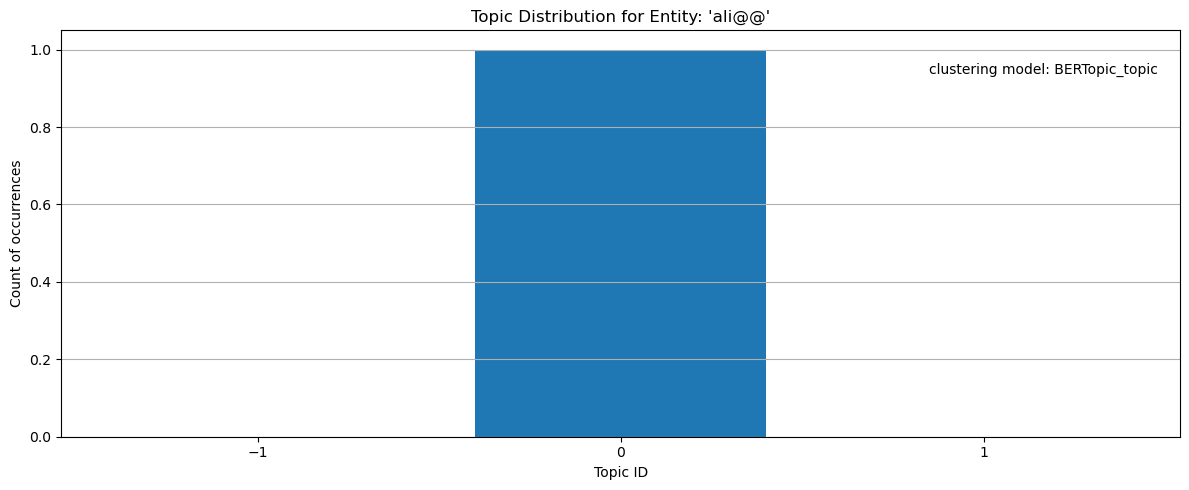

In [75]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_counts_df = entity_topic_counts(df, entity_col_name, topic_col)
display(entity_topic_counts_df.head())

entity = entity_topic_counts_df.index[0]   # first entity
plot_entity_topic_counts(entity=entity, entity_topic_counts=entity_topic_counts_df, clustering_model=topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [76]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | list
urls                           | list
account_mentions               | list
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic                  | int32
ner_entities                   | list


In [77]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)


write_report("Finised Runnign Susscsefuly")

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2025_12_28/Topic_Ner_Ecuador_part_3.gzip.parquet
2025-12-28 11:12:18 | Finised Runnign Susscsefuly
